<a href="https://colab.research.google.com/drive/17oZsgVNAo5Y6cEpiZlEgybF2bjUAkXHt?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CE 400/500: AI for Chemical Engineers
# Hands-on: Optimizing the Synthesis Conditions for Metal-Organic Frameworks (MOFs) Using Genetic Algorithm

Instructor: Kaihang Shi, Assistant Professor of Chemical & Biological Engineering at the University at Buffalo

**Learning objectives:**
- Understand how genetic algorithm can optimize MOF synthesis to reach a higher BET surface area.
- Implement a GA to optimize synthesis parameters with equal/unequal weights and starts from existing CuBTC trials.
- Evaluate GA performance with a pre-trained BET surface area predictor and compare GA performance with random search.
- Explore how different starting populations would affect the optimization results

**References:**
- S.M. Moosavi, A. Chidambaram, L. Talirz, M. Haranczyk, K.C. Stylianou, and B. Smit, “Capturing chemical intuition in synthesis of metal-organic frameworks,” Nat. Commun. 10(1), 539 (2019).
- CE 400/500 Lecture 16: Introduction to Prescriptive AI

## 0. Background

The following scheme shows the autonomous optimization workflow for synthesizing HKUST-1 with a higher BET surface area, as discussed in Moosavi et al. (2019). The original workflow leveraged the real robotic experiments and characterization to evaluate the fitness function. For convenience, in this tutorial, we replaced the robotic experiment step with a pre-trained random forest (RF) model that can directly predict MOF's BET surface area based on the synthesis parameters. This RF model was trained using the experimental data from the Moosavi et al. (2019).  

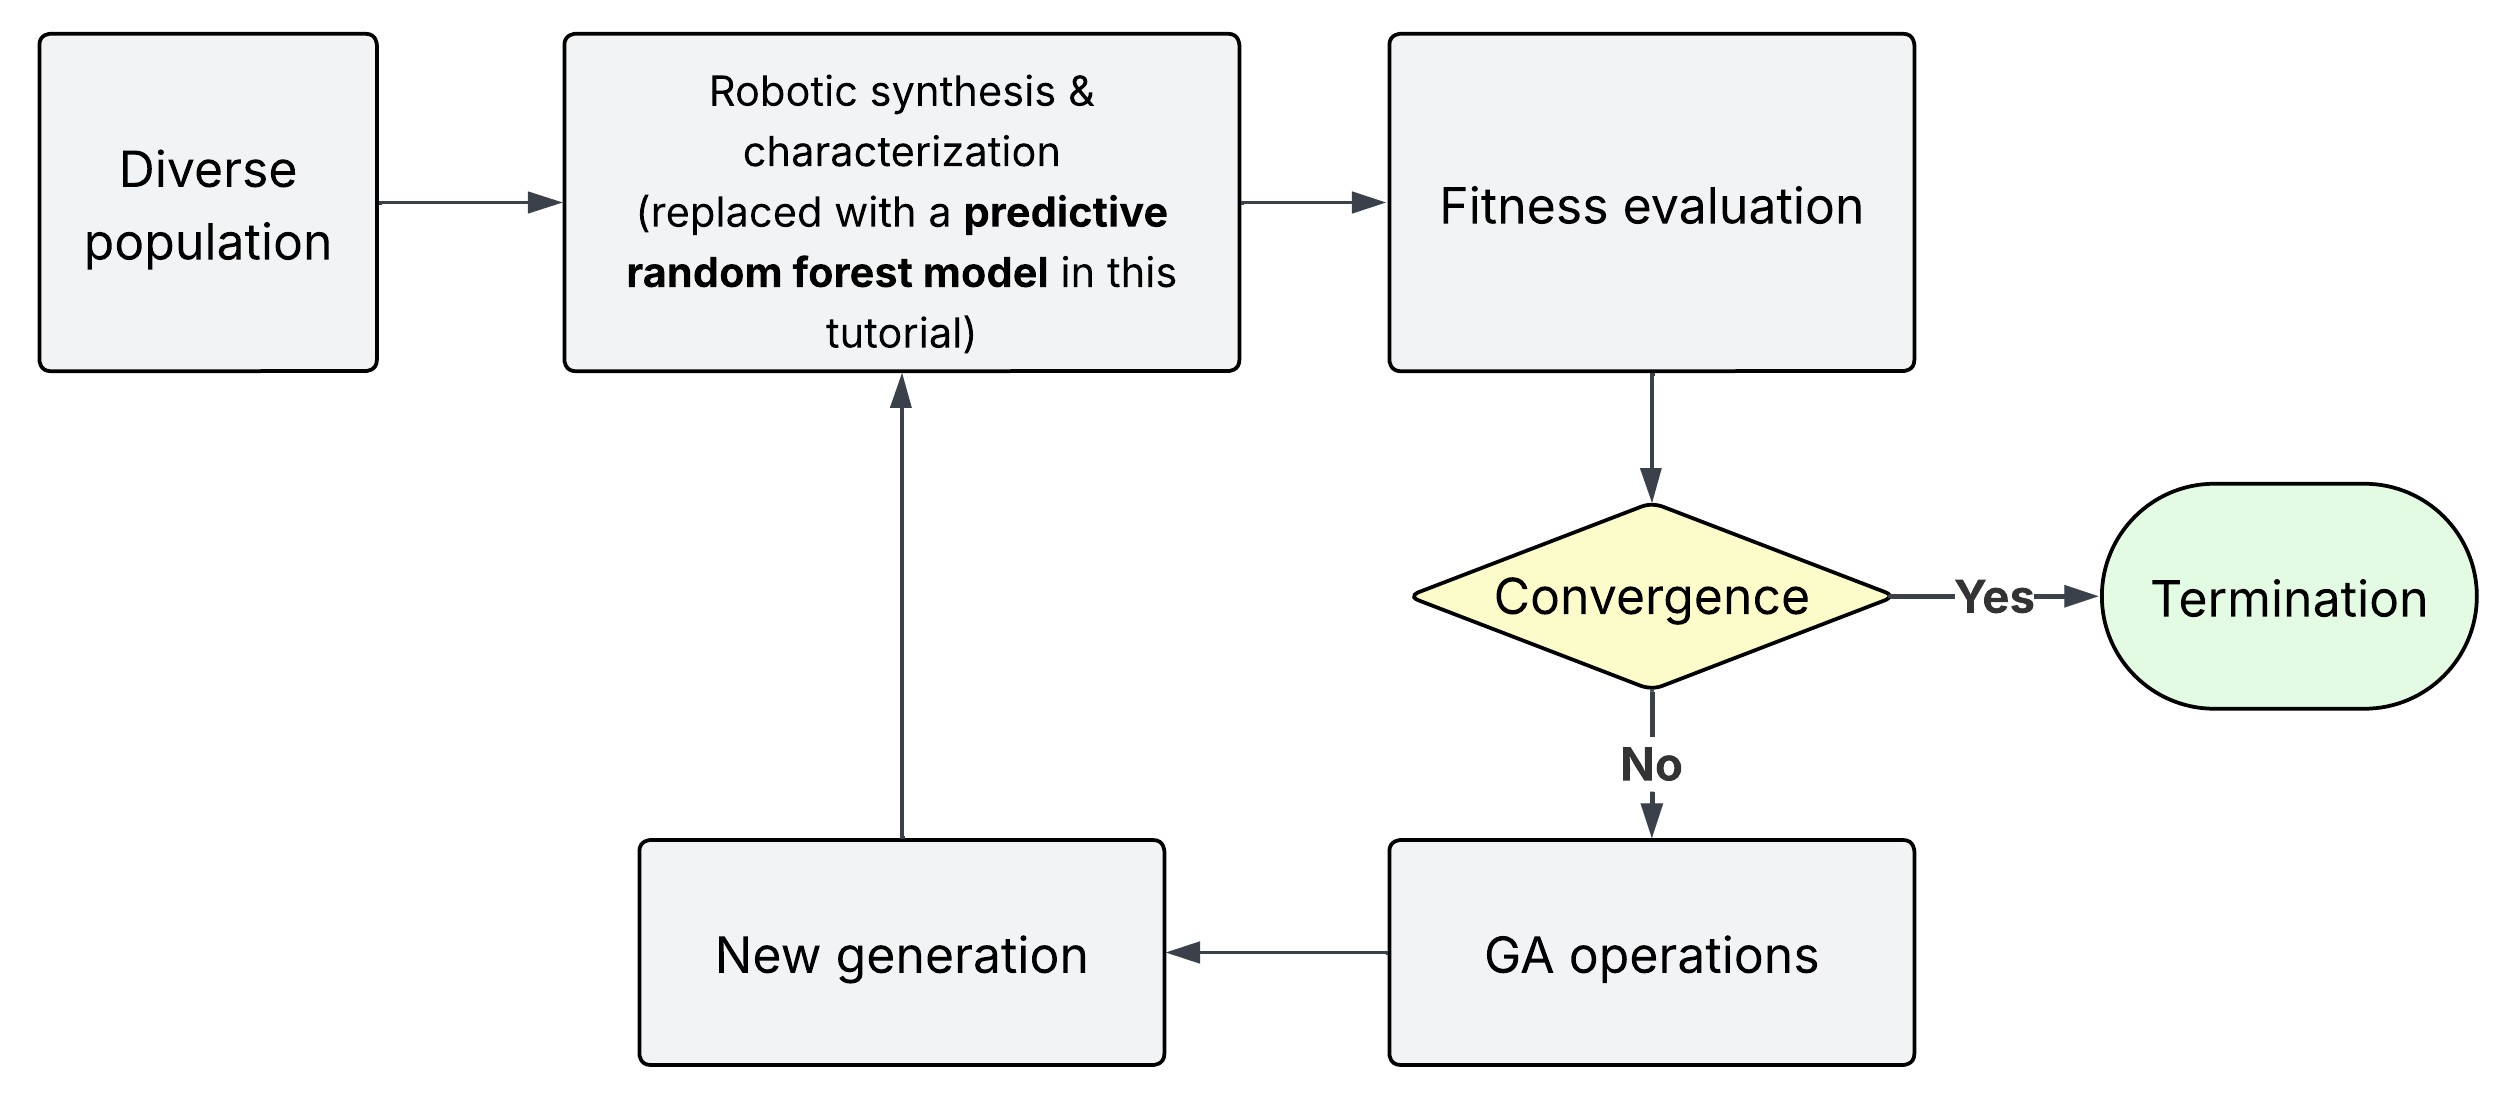

## 1. Dataset and Pre-Trained Random Forest Model

Let's first download essential data and model we need for this tutorial, including the pre-trained random forest (RF) model to predict MOF's surface area based on synthesis parameters. We will use this RF model to evaluate the fitness in the GA workflow later. The unzipped folder `saved_models` will be stored temporarily in the Colab file space.

In [ ]:
import zipfile
import urllib.request

# Dropbox link (force direct download)
zip_url = (
    "https://www.dropbox.com/scl/fi/lbhdb77bn720zdvs970g6/saved_models.zip"
    "?rlkey=0lpt1gxhysa72u4zxt6ga5ivi&st=dwkk6v5z&dl=1"
)

zip_path = "./saved_models.zip"

print(f"Downloading {zip_url} -> {zip_path} ...")
urllib.request.urlretrieve(zip_url, zip_path)
print("Download complete. Extracting...")

# unzip the downloaded file
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall("./")


Download complete. Extracting...


In this tutorial, we will optimize nine synthesis variables, so that each "chromosome" contains 9 genes.

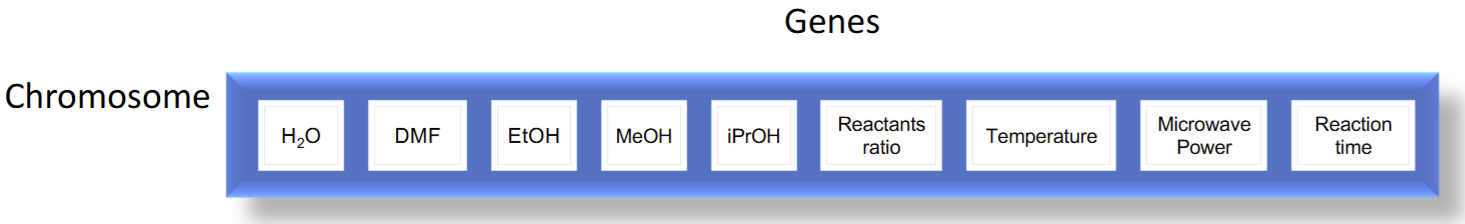

| Synthesis variable               | Optimisation constraints | Notes                                                                 |
|------------------------------------|---------------------------|-----------------------------------------------------------------------|
| Water (H₂O)                        | 0 – 6 ml                  |                                                                       |
| Dimethylformamide (DMF)           | 0 – 6 ml                  | The total solvent volume is constrained to be between 1 ml to 6 ml.   |
| Ethanol (EtOH)                    | 0 – 6 ml                  |                                                                       |
| Methanol (MeOH)                   | 0 – 6 ml                  |                                                                       |
| Isopropyl alcohol (iPrOH)         | 0 – 6 ml                  |                                                                       |
| Reactants ratio                   | 0.8 – 1.8                 | Molar ratio of Cu nitride to BTC ligands                              |
| Temperature                       | 100 – 200 °C             |                                                                       |
| Microwave power                   | 150 – 250 W               |                                                                       |
| Reaction time                     | 2 – 60 mins               |                                                                       |


In [ ]:
import json

# read in features in the same sequence as in the RF model
with open("./saved_models/feature_names.json") as f:
    feature_cols = json.load(f)

feature_cols

['H2O_ml',
 'DMF_ml',
 'EeOH_ml',
 'MeOH_ml',
 'iPrOH_ml',
 'Reactants_ratio',
 'Temp_degreeC',
 'Microwave_power_W',
 'React_time_min']

Let's specify feature bounds based on the values in the table above:

In [ ]:
# specify bounds based on constraints in the original paper
custom_bounds = {
    "H2O_ml": (0, 6),
    "DMF_ml": (0, 6),
    "EeOH_ml": (0, 6),
    "MeOH_ml": (0, 6),
    "iPrOH_ml": (0, 6),
    "Reactants_ratio": (0.8, 1.8),
    "Temp_degreeC": (100, 200),
    "Microwave_power_W": (150, 250),
    "React_time_min": (2, 60)
}

# construct feature_bounds to match the order in feature_cols
feature_bounds = {col: custom_bounds[col] for col in feature_cols}

feature_bounds

{'H2O_ml': (0, 6),
 'DMF_ml': (0, 6),
 'EeOH_ml': (0, 6),
 'MeOH_ml': (0, 6),
 'iPrOH_ml': (0, 6),
 'Reactants_ratio': (0.8, 1.8),
 'Temp_degreeC': (100, 200),
 'Microwave_power_W': (150, 250),
 'React_time_min': (2, 60)}

We will use the first 30 CuBTC synthesis experiments in `CuBTC_synthesis.csv` as the initial population for the GA workflow. This 30 sets of synthesis parameters are the diverse initial set originally used in the Moosavi's paper.

In [ ]:
import pandas as pd

# download "CuBTC_synthesis.csv"
url = 'https://www.dropbox.com/scl/fi/yobh8z3c5pv7hmdsj93iv/CuBTC_synthesis.csv?rlkey=5rp8oghpqw0fqw5m6nd752123&st=z1nflhr5&dl=1'
df = pd.read_csv(url)

df.columns = df.columns.str.strip()

# specify the initial population for GA
initial_pop = df[feature_cols].iloc[:30].reset_index(drop=True)
print(f'Initial pool shape: {initial_pop.shape}')

initial_pop.describe().T[['mean', 'std', 'min', 'max']]

Initial pool shape: (30, 9)


,mean,std,min,max
H2O_ml,1.266667,1.915154,0.0,5.5
DMF_ml,1.150000,1.871520,0.0,5.5
EeOH_ml,1.100000,1.849511,0.0,5.0
MeOH_ml,1.033333,1.902509,0.0,6.0
iPrOH_ml,1.000000,1.691765,0.0,5.5
Reactants_ratio,1.326667,0.407628,0.8,1.8
Temp_degreeC,147.733333,37.720326,100.0,200.0
Microwave_power_W,198.533333,41.026260,150.0,250.0
React_time_min,30.100000,22.825198,2.0,60.0


Here, following the original work and for the convenience of seeing gene values directly in physical units, we retain the original scale of each gene. However, it is generally recommended to normalize genes to the same scale for efficient optimization, especially for genes showing several OOM difference in scale. The normalization is usually based on the statistics of initial population.

Now let's set up the pre-trained random forest model stored in `saved_models/champion_bet_model.joblib`. This RF model will act as our fitness function to predict BET surface area based on the input synthesis parameters. In practice, this model could be replaced with robotic experiments for more accurate and realistic fitness evaluation.

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


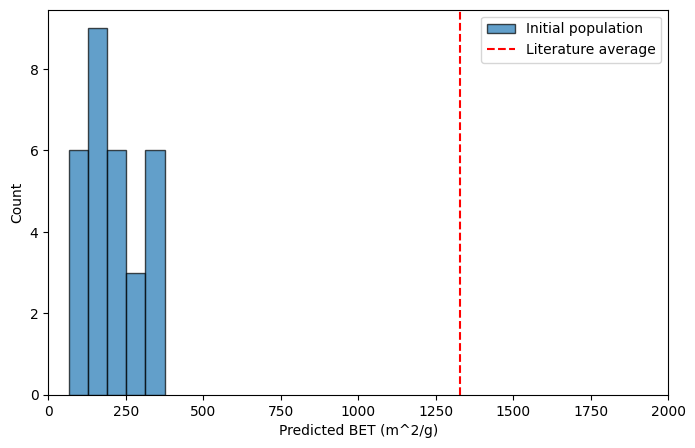

In [ ]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42

# load the RF model from the downloaded file
bet_model = joblib.load("./saved_models/champion_bet_model.joblib")

# define a function to predict BET area (m^2/g) based on synthesis parameters input
def predict_bet(candidates: pd.DataFrame):
    return bet_model.predict(candidates).astype(float)

# evaluate BET surface area of initial population of synthesis conditions
initial_predictions = predict_bet(initial_pop)

# plot distribution of predictions for initial population
# and compare initial population values with literature average (optional)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(initial_predictions, bins=5, edgecolor='k', alpha=0.7, label='Initial population')
ax.set_xlabel('Predicted BET (m^2/g)')
ax.set_ylabel('Count')
ax.set_xlim(0,2000)
ax.axvline(x=1330, color='r', linestyle='--', label='Literature average')
ax.legend()
plt.show()

## 2. Genetic Algorithm




Genetic algorithm are inspired by the process of natural evolution, where the fittest individuals survive and pass on their traits.



### 2.1 Define GA Workflows


Here we will implement a lightweight GA:
1. Evaluate the current population with the BET surface area predictor.
2. Select parents using Roulette wheel with probabilities proportional to fitness scores.
3. Create children through linear crossover.
4. Apply mutations to offsprings from crossover operation by resampling features uniformly within their observed bounds.
5. Retain a small fraction of unchanged, original top-performing chromosomes from the current population for next generation.

In [ ]:
# define a GA workflow function
def run_genetic_algorithm(
    initial_pop,             # initial population, Pandas DataFrame
    feature_cols,            # list of feature names
    feature_bounds,          # constraints of optimization space for each feature, dictionary
    population_size,         # number of samples each generation
    generations,             # number of generations
    elite_fraction,          # Fraction of best individuals to keep as elites
    mutation_rate,           # Probability of mutation for each gene
    seed):

    # Initialize random number generator for reproducibility
    rng = np.random.default_rng(seed)

    # Assign initial population
    population = initial_pop

    # Lists to store results and population snapshots for analysis
    history = []
    snapshots = []

    # Initialize the best solution found so far with a very low score
    best_solution = {'score': -np.inf, 'features': None}

    # Main loop for the genetic algorithm generations
    for generation in range(1, generations + 1):

        # --- Step 1: Evaluate Fitness ---
        # Predict the BET surface area for each individual (synthesis condition) in the current population
        fitness = predict_bet(population)

        # Find the best individual (highest predicted BET) in the current generation
        best_idx = int(np.argmax(fitness))
        best_score = float(fitness[best_idx])
        mean_score = float(fitness.mean())
        best_candidate = population.iloc[best_idx][feature_cols].copy()

        # Update the overall best solution if the current generation has a better one
        if best_score > best_solution['score']:
            best_solution = {
                'score': best_score,
                'features': best_candidate.copy()
            }

        # Record the performance of the current generation
        record = {
            'Generation': generation,
            'Best_predicted_BET_m2g': best_score,
            'Mean_predicted_BET_m2g': mean_score,
        }

        # Also record the synthesis parameters of the best individual
        for col in feature_cols:
            record[f'Best_{col}'] = best_candidate[col]
        history.append(record)

        # Store a snapshot of the current population's synthesis parameters
        snapshots.append(population[feature_cols].copy())

        # --- Step 2: Select Elites ---
        # Determine the number of elite individuals to carry over to the next generation
        elite_count = max(1, int(round(elite_fraction * population_size)))
        # Get the indices of the elite individuals (those with the highest fitness)
        elite_indices = np.argsort(fitness)[-elite_count:]
        # Select the elite individuals' synthesis parameters
        elite = population.iloc[elite_indices][feature_cols].reset_index(drop=True)

        # Start building the new population for next generation with the elite individuals
        new_population = elite

        # --- Step 3: Crossover and Mutation ---
        # Use fitness proportional selection (Roulette Wheel) for parent selection
        # Handle negative fitness scores by shifting to be non-negative
        shifted_fitness = fitness - fitness.min()
        selection_probs = shifted_fitness / shifted_fitness.sum() if shifted_fitness.sum() > 0 else np.ones_like(fitness) / len(fitness)

        # Continue creating new individuals until the population reaches the desired size
        while len(new_population) < population_size:

            # --- Crossover ---
            # Select two parent individuals from the entire population based on fitness
            parent_indices = rng.choice(len(population), size=2, replace=True, p=selection_probs)
            parent_a = population.iloc[int(parent_indices[0])][feature_cols].to_numpy(dtype=float)
            parent_b = population.iloc[int(parent_indices[1])][feature_cols].to_numpy(dtype=float)

            # Perform linear crossover: child = parent1 + random_number * (parent2-parent1)
            random_number = rng.random(len(feature_cols))
            child = parent_a + random_number * (parent_b - parent_a)

            # --- Mutation ---
            # Apply mutation to the child: for each gene, with a certain probability,
            # replace the gene's value with a random value within its bounds
            for i, col in enumerate(feature_cols):
                if rng.random() < mutation_rate:
                    low, high = feature_bounds[col]
                    child[i] = rng.uniform(low, high)

            # Add the newly created child to the new population
            # Convert child to DataFrame before concatenating
            new_population = pd.concat([new_population, pd.DataFrame([child], columns=feature_cols)], ignore_index=True)


        # Replace the old population with the new generation
        population = new_population

    # Convert the history list to a pandas DataFrame for easier analysis
    history_df = pd.DataFrame(history)

    # Return the history, snapshots of populations, and the best solution found
    return history_df, snapshots, best_solution

### 2.2 GA Optimization Results
Now, let's perform the GA to optimize the synthesis conditions of HKUST-1:



In [ ]:
ga_history, ga_snapshots, ga_best = run_genetic_algorithm(
    initial_pop = initial_pop,             # initial population, Pandas DataFrame
    feature_cols = feature_cols,           # list of feature names
    feature_bounds = feature_bounds,       # constraints of optimization space for each feature, dictionary
    population_size = 30,                  # number of samples each generation
    generations = 50,                      # number of generations
    elite_fraction = 0.2,                  # Fraction of best individuals to keep as elites
    mutation_rate = 1/9,                   # Probability of mutation for each gene
    seed = RANDOM_SEED)

In [ ]:
ga_history

,Generation,Best_predicted_BET_m2g,Mean_predicted_BET_m2g,Best_H2O_ml,Best_DMF_ml,Best_EeOH_ml,Best_MeOH_ml,Best_iPrOH_ml,Best_Reactants_ratio,Best_Temp_degreeC,Best_Microwave_power_W,Best_React_time_min
0,1,376.064318,211.755249,0.500000,0.500000,0.000000,5.000000,0.000000,1.700000,132.000000,152.000000,44.000000
1,2,463.683188,308.769534,1.942282,0.472750,2.157081,0.478825,1.768291,1.396705,179.725982,208.935072,21.614068
2,3,788.185266,365.018161,0.043186,0.997447,1.462005,4.914440,0.000000,1.473211,137.185979,200.180615,23.263286
3,4,788.185266,441.045943,0.043186,0.997447,1.462005,4.914440,0.000000,1.473211,137.185979,200.180615,23.263286
4,5,812.997565,541.584480,0.408882,1.224258,1.817244,4.172880,1.640993,1.622244,144.001097,199.253887,29.573650
5,6,985.278592,608.893702,0.481039,1.842152,2.062691,2.928671,4.742677,1.557461,141.478299,198.954751,30.035956
6,7,985.278592,699.150206,0.481039,1.842152,2.062691,2.928671,4.742677,1.557461,141.478299,198.954751,30.035956
7,8,991.641568,735.521012,0.366765,2.480322,1.876408,5.516899,2.629007,1.465313,140.294899,198.874067,30.215785
8,9,991.641568,823.495247,0.366765,2.480322,1.876408,5.516899,2.629007,1.465313,140.294899,198.874067,30.215785
9,10,991.641568,884.058283,0.366765,2.480322,1.876408,5.516899,2.629007,1.465313,140.294899,198.874067,30.215785


In [ ]:
print(f"Best predicted BET: {ga_best['score']:.1f} m^2/g")
ga_best_df = ga_best['features'].to_frame(name='Optimal value').reset_index().rename(columns={'index': 'Feature'})
ga_best_df


Best predicted BET: 1074.4 m^2/g


,Feature,Optimal value
0,H2O_ml,0.501154
1,DMF_ml,2.001331
2,EeOH_ml,2.060022
3,MeOH_ml,0.197956
4,iPrOH_ml,5.480369
5,Reactants_ratio,1.485198
6,Temp_degreeC,139.781173
7,Microwave_power_W,197.812082
8,React_time_min,20.058632


If we compare our optimized synthesis conditions with those obtained with real robotic experiments in Moosavi et al (2019), we see favorable agreement between the two, although our GA workflow is a simplified version and used a rough RF predictor for BET surface area.

| Feature               | This tutorial | Moosavi et al. |
|------------------------|---------------|---------------|
| H₂O (ml)               | 0.50         | 0.5           |
| DMF (ml)               | 2.00         | 2.5           |
| EtOH (ml)              | 2.06         | 2.0           |
| MeOH (ml)              | 0.20         | 0.0           |
| iPrOH (ml)             | 5.48         | 0.0           |
| Reactants ratio        | 1.49         | 1.5           |
| Temperature (°C)       | 139.78       | 140           |
| Microwave power (W)    | 197.81       | 200           |
| Reaction time (min)    | 20.06        | 20            |


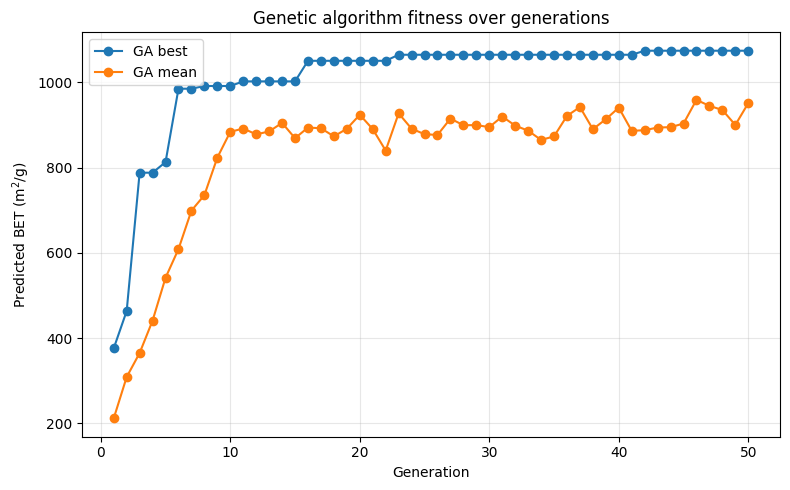

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ga_history['Generation'], ga_history['Best_predicted_BET_m2g'], marker='o', label='GA best')
ax.plot(ga_history['Generation'], ga_history['Mean_predicted_BET_m2g'], marker='o', label='GA mean')
ax.set_xlabel('Generation')
ax.set_ylabel('Predicted BET (m$^2$/g)')
ax.set_title('Genetic algorithm fitness over generations')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


**Exercise**❗:
- Play with the value of `mutation_rate`, e.g., setting it to 1 or a very small number (like 0) to see how it affects the exploration-exploitation tradeoff in GA.
- Play with a different crossover scheme like uniform crossover to see how the efficiency of GA changes.

### 2.3 Comparison to Random Search

To benchmark efficiency of GA, we run a random search. Each iteration samples the synthesis variables uniformly within the experimental bounds, without using any feedback from previous trials.

Let's set up the random search function:

In [ ]:
# Baseline search that samples conditions uniformly without using feedback.
def run_random_search(
    feature_cols,
    feature_bounds,
    evaluations_per_generation,
    generations,
    seed):

    rng = np.random.default_rng(seed)
    history = []
    best_so_far = -np.inf

    for generation in range(1, generations + 1):

        # uniformly generate random value in the specified bounds for each gene/feature
        samples = {
            col: rng.uniform(low, high, size=evaluations_per_generation)
            for col, (low, high) in feature_bounds.items()
        }

        # convert to Pandas dataframe
        population = pd.DataFrame(samples, columns=feature_cols)
        # evaluate the fitness using the same BET predictor
        fitness = predict_bet(population)
        generation_best = float(fitness.max())
        generation_mean = float(fitness.mean())
        if generation_best > best_so_far:
            best_so_far = generation_best

        # save information to history trajectory
        history.append({
            'Generation': generation,
            'Random_best_BET_m2g': best_so_far,
            'Random_mean_BET_m2g': generation_mean,
        })

    return pd.DataFrame(history)


Now let's run a random search that resembles the traditional trial-and-error search:

In [ ]:
random_history = run_random_search(
    feature_cols=feature_cols,
    feature_bounds=feature_bounds,
    evaluations_per_generation=30,   # set to the same value as the population_size
    generations=50,
    seed=RANDOM_SEED
    )


Let's compare GA and random search

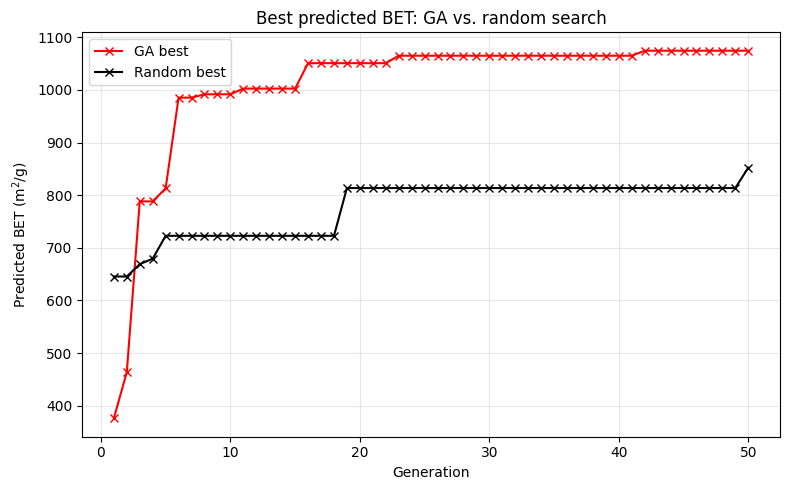

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ga_history['Generation'], ga_history['Best_predicted_BET_m2g'], marker='x', color='red', label='GA best')
ax.plot(random_history['Generation'], random_history['Random_best_BET_m2g'], marker='x', color='black', label='Random best')
ax.set_xlabel('Generation')
ax.set_ylabel('Predicted BET (m$^2$/g)')
ax.set_title('Best predicted BET: GA vs. random search')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

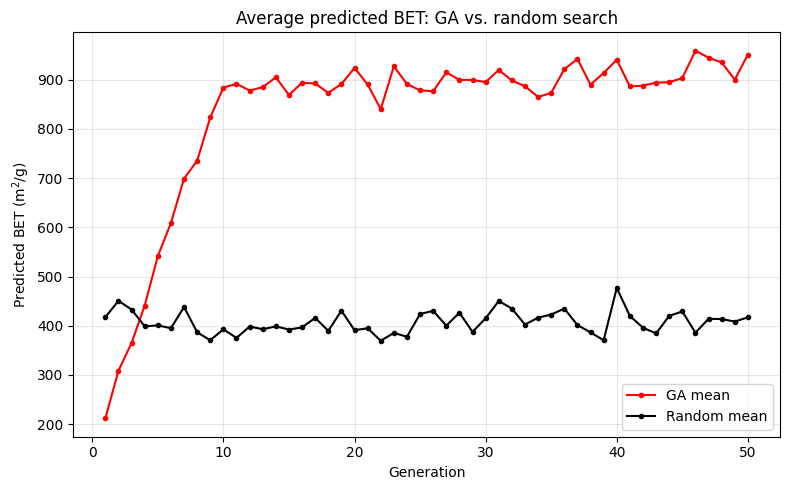

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ga_history['Generation'], ga_history['Mean_predicted_BET_m2g'], marker='.', color='red', label='GA mean')
ax.plot(random_history['Generation'], random_history['Random_mean_BET_m2g'], marker='.', color='black', label='Random mean')
ax.set_xlabel('Generation')
ax.set_ylabel('Predicted BET (m$^2$/g)')
ax.set_title('Average predicted BET: GA vs. random search')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Effect of Initial Population

Non-diverse initial pool shape: (30, 9)


,mean,std,min,max
H2O_ml,0.5,0.000000e+00,0.5,0.5
DMF_ml,0.0,0.000000e+00,0.0,0.0
EeOH_ml,5.0,0.000000e+00,5.0,5.0
MeOH_ml,0.0,0.000000e+00,0.0,0.0
iPrOH_ml,1.0,0.000000e+00,1.0,1.0
Reactants_ratio,0.9,4.516810e-16,0.9,0.9
Temp_degreeC,120.0,0.000000e+00,120.0,120.0
Microwave_power_W,174.0,0.000000e+00,174.0,174.0
React_time_min,58.0,0.000000e+00,58.0,58.0


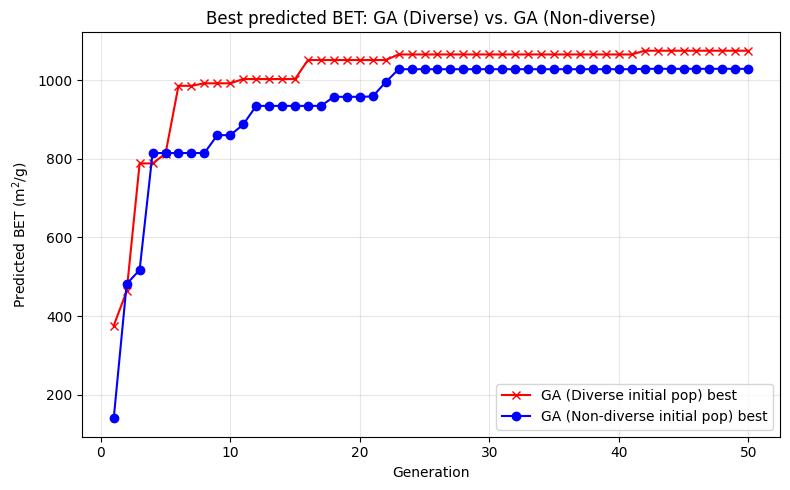

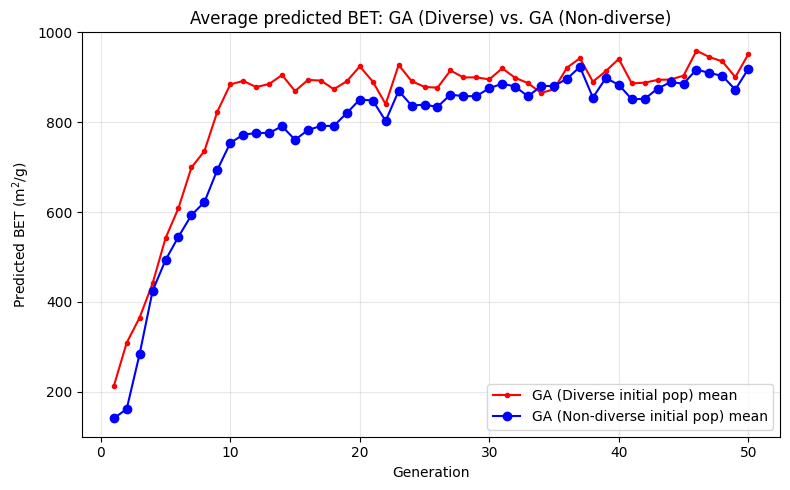

In [ ]:
# Generate a non-diverse artificial initial population
# We can do this by taking one sample from the original initial_pop and replicating it
non_diverse_initial_pop = initial_pop.iloc[[0] * 30].reset_index(drop=True)
print(f'Non-diverse initial pool shape: {non_diverse_initial_pop.shape}')
display(non_diverse_initial_pop.describe().T[['mean', 'std', 'min', 'max']])


# Run GA with the non-diverse initial population
ga_history_nondiverse, ga_snapshots_nondiverse, ga_best_nondiverse = run_genetic_algorithm(
    initial_pop = non_diverse_initial_pop,
    feature_cols = feature_cols,
    feature_bounds = feature_bounds,
    population_size = 30,
    generations = 50,
    elite_fraction = 0.2,
    mutation_rate = 1/9,
    seed = RANDOM_SEED)

# Plot comparison of GA with diverse and non-diverse initial populations
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ga_history['Generation'], ga_history['Best_predicted_BET_m2g'], marker='x', color='red', label='GA (Diverse initial pop) best')
ax.plot(ga_history_nondiverse['Generation'], ga_history_nondiverse['Best_predicted_BET_m2g'], marker='o', color='blue', label='GA (Non-diverse initial pop) best')
ax.set_xlabel('Generation')
ax.set_ylabel('Predicted BET (m$^2$/g)')
ax.set_title('Best predicted BET: GA (Diverse) vs. GA (Non-diverse)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ga_history['Generation'], ga_history['Mean_predicted_BET_m2g'], marker='.', color='red', label='GA (Diverse initial pop) mean')
ax.plot(ga_history_nondiverse['Generation'], ga_history_nondiverse['Mean_predicted_BET_m2g'], marker='o', color='blue', label='GA (Non-diverse initial pop) mean')
ax.set_xlabel('Generation')
ax.set_ylabel('Predicted BET (m$^2$/g)')
ax.set_title('Average predicted BET: GA (Diverse) vs. GA (Non-diverse)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

- GA is generally robust with different choice of hyperparameters and initial population.
- Choice of initial population is critical and it will affect the chance of finding global optimum and the efficiency of GA workflow. (You can try tuning hyperparameters to see the effect, it would be hard for non-diverse case to find the same best BET area compared to the diverse case).

**Going further:** we could retrieve feature importance from predictive RF model. Can we take advantage of this feature importance to bias the choice of initial population, crossover or mutation operations to make GA more efficient? Try this after class or in your final project.

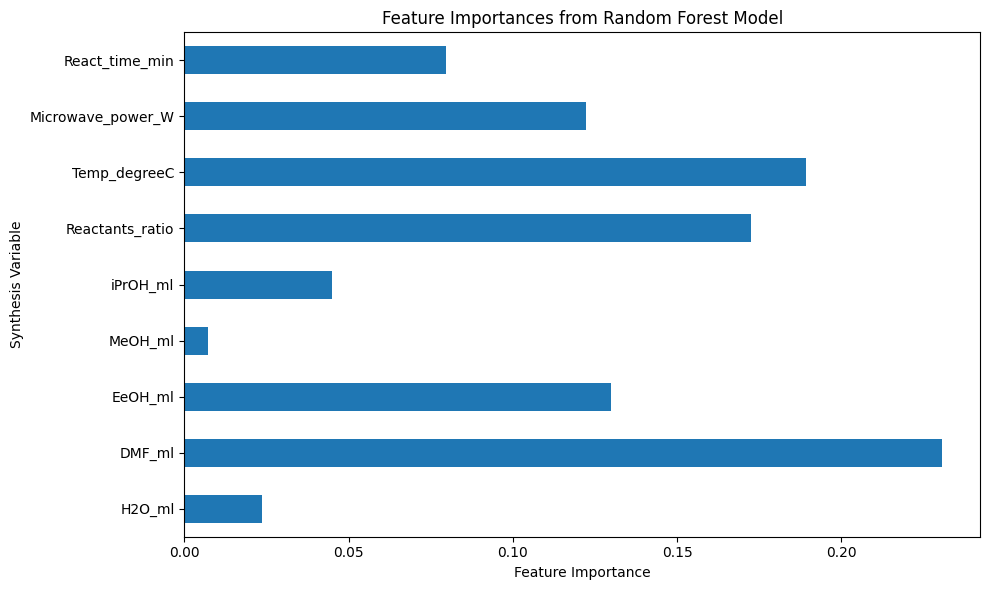

In [ ]:
# Get feature importances from the trained model
feature_importances = pd.Series(bet_model.feature_importances_, index=feature_cols)

# Plot feature importances
fig, ax = plt.subplots(figsize=(10, 6))
feature_importances.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Synthesis Variable')
ax.set_title('Feature Importances from Random Forest Model')
plt.tight_layout()
plt.show()